In [6]:
# ============================================================
# WEEK 2 CELL 1 — Install MobileSAM
# ============================================================

!pip install -q git+https://github.com/ChaoningZhang/MobileSAM.git
!wget -q --show-progress \
    https://github.com/ChaoningZhang/MobileSAM/raw/master/weights/mobile_sam.pt \
    -O mobile_sam.pt

import os
print(f"MobileSAM weights: {os.path.getsize('mobile_sam.pt')/1e6:.1f} MB")

  Preparing metadata (setup.py) ... done
mobile_sam.pt       100%[===================>]  38.84M  --.-KB/s    in 0.09s   
MobileSAM weights: 40.7 MB


In [7]:
!pip install -q git+https://github.com/facebookresearch/segment-anything-2.git
!pip install -q matplotlib numpy opencv-python Pillow requests

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 8.5 MB/s eta 0:00:00


In [8]:
# ============================================================
# CELL 3 — Download SAM2 model weights and load it
# This downloads ~180MB. Takes 1-2 minutes.
# ============================================================

import torch
import os

# Download the SAM2 checkpoint (small variant - faster for Colab)
!wget -q --show-progress \
    https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt \
    -O sam2_small.pt

print("Download complete.")
print(f"File size: {os.path.getsize('sam2_small.pt') / 1e6:.1f} MB")

# # Check if GPU is available
# device = "cuda" if torch.cuda.is_available() else "cpu"
# print(f"Running on: {device}")

# if device == "cpu":
#     print("WARNING: No GPU detected. Go to Runtime → Change runtime type → T4 GPU")

sam2_small.pt       100%[===================>] 175.87M   357MB/s    in 0.5s    
Download complete.
File size: 184.4 MB


In [9]:
# ============================================================
# WEEK 2 CELL 2 — Load SAM2 and MobileSAM together
# ============================================================

import torch
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# --- Load SAM2 (same as Week 1) ---
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

sam2_model = build_sam2(
    config_file="configs/sam2.1/sam2.1_hiera_s.yaml",
    ckpt_path="sam2_small.pt",
    device=device
)
sam2_predictor = SAM2ImagePredictor(sam2_model)
print(f"SAM2 loaded — {sum(p.numel() for p in sam2_model.parameters())/1e6:.1f}M parameters")

# --- Load MobileSAM ---
from mobile_sam import sam_model_registry, SamPredictor

mobile_model = sam_model_registry["vit_t"](checkpoint="mobile_sam.pt")
mobile_model = mobile_model.to(device)
mobile_model.eval()
mobile_predictor = SamPredictor(mobile_model)
print(f"MobileSAM loaded — {sum(p.numel() for p in mobile_model.parameters())/1e6:.1f}M parameters")

print("\nBoth models ready.")

Device: cuda
SAM2 loaded — 46.1M parameters


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/usr/local/lib/python3.12/dist-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_11m

MobileSAM loaded — 10.1M parameters

Both models ready.


In [10]:
# ============================================================
# CELL 5 — Install nibabel (reads .nii MRI files)
# ============================================================

!pip install -q nibabel

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

print("nibabel version:", nib.__version__)
print("Ready to load .nii files")

nibabel version: 5.4.2
Ready to load .nii files


In [11]:
# ============================================================
# WEEK 2 CELL 3 — Reload ACDC data + helper functions
# ============================================================

# Load patient100 slice 4 — same slice as Week 1
from google.colab import drive
drive.mount('/content/drive')

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# ---- Load the MRI scan ----
mri_path = '/content/drive/MyDrive/patient100/patient100_frame01.nii.gz'
gt_path  = '/content/drive/MyDrive/patient100/patient100_frame01_gt.nii.gz'

mri_nib = nib.load(mri_path)
gt_nib  = nib.load(gt_path)

mri_data = mri_nib.get_fdata()
gt_data  = gt_nib.get_fdata()

# Same slice and preprocessing as Week 1
SLICE_IDX = 3

def preprocess_slice(mri_data, slice_idx):
    sl = mri_data[:, :, slice_idx]
    sl = (sl - sl.min()) / (sl.max() - sl.min())
    sl_uint8 = (sl * 255).astype(np.uint8)
    return np.stack([sl_uint8]*3, axis=-1)  # H x W x 3

def get_combined_box(gt_data, slice_idx):
    """Auto-generate bounding box from ground truth mask"""
    gt_slice = gt_data[:, :, slice_idx]
    fg = gt_slice > 0
    rows = np.any(fg, axis=1)
    cols = np.any(fg, axis=0)
    y_min, y_max = np.where(rows)[0][[0, -1]]
    x_min, x_max = np.where(cols)[0][[0, -1]]
    pad = 5
    H, W = gt_slice.shape
    return np.array([
        max(0, x_min-pad), max(0, y_min-pad),
        min(W-1, x_max+pad), min(H-1, y_max+pad)
    ])

def dice_score(pred_mask, gt_mask):
    pred = pred_mask.astype(bool)
    gt   = (gt_mask > 0).astype(bool)
    intersection = (pred & gt).sum()
    if pred.sum() + gt.sum() == 0:
        return 1.0
    return 2 * intersection / (pred.sum() + gt.sum())

mri_rgb  = preprocess_slice(mri_data, SLICE_IDX)
gt_slice = gt_data[:, :, SLICE_IDX]
clean_box = get_combined_box(gt_data, SLICE_IDX)

print(f"MRI slice shape: {mri_rgb.shape}")
print(f"Clean box: {clean_box}")
print(f"GT unique labels: {np.unique(gt_slice)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MRI slice shape: (216, 304, 3)
Clean box: [106  58 185 130]
GT unique labels: [0. 1. 2. 3.]


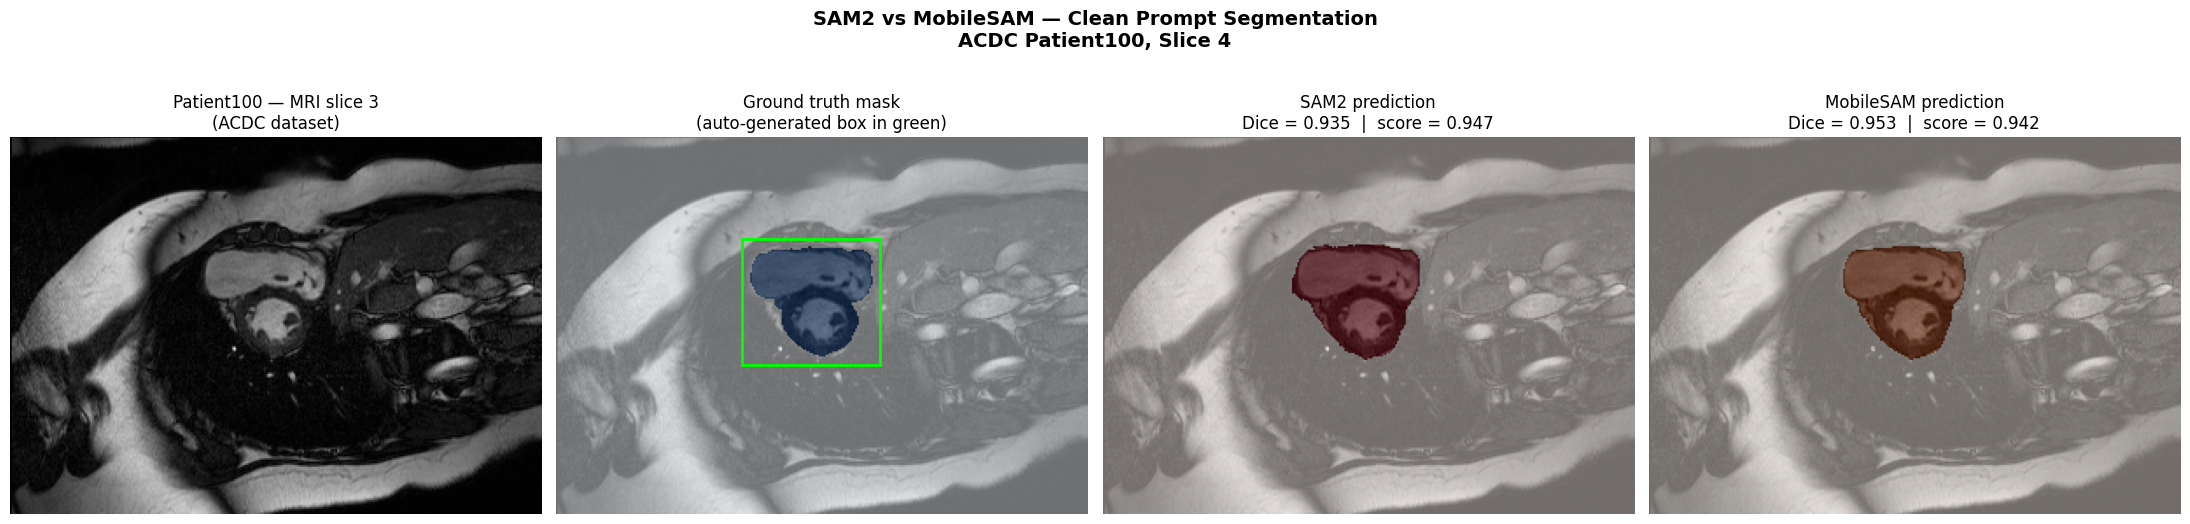


Clean prompt results:
  SAM2      Dice = 0.9349
  MobileSAM Dice = 0.9535
  Difference     = -0.0186


In [12]:
# ============================================================
# WEEK 2 CELL 1 — See what MobileSAM actually segments
# on patient100 with a clean prompt
# ============================================================

mobile_predictor.set_image(mri_rgb)

with torch.inference_mode():
    masks_mobile, scores_mobile, _ = mobile_predictor.predict(
        point_coords=None,
        point_labels=None,
        box=clean_box[None, :],
        multimask_output=False,
    )

# Also re-run SAM2 for direct visual comparison
sam2_predictor.set_image(mri_rgb)
with torch.inference_mode():
    masks_sam2, scores_sam2, _ = sam2_predictor.predict(
        point_coords=None,
        point_labels=None,
        box=clean_box[None, :],
        multimask_output=False,
    )

dice_mobile = dice_score(masks_mobile[0], gt_slice)
dice_sam2   = dice_score(masks_sam2[0],   gt_slice)

fig, axes = plt.subplots(1, 4, figsize=(22, 6))

# Panel 1 — raw MRI
axes[0].imshow(mri_rgb, cmap='gray')
axes[0].set_title("Patient100 — MRI slice 3\n(ACDC dataset)", fontsize=12)
axes[0].axis('off')

# Panel 2 — ground truth
axes[1].imshow(mri_rgb, cmap='gray')
axes[1].imshow(gt_slice > 0, alpha=0.45, cmap='Blues')
rect = patches.Rectangle(
    (clean_box[0], clean_box[1]),
    clean_box[2]-clean_box[0], clean_box[3]-clean_box[1],
    linewidth=2, edgecolor='lime', facecolor='none'
)
axes[1].add_patch(rect)
axes[1].set_title("Ground truth mask\n(auto-generated box in green)", fontsize=12)
axes[1].axis('off')

# Panel 3 — SAM2 output
axes[2].imshow(mri_rgb, cmap='gray')
axes[2].imshow(masks_sam2[0], alpha=0.45, cmap='Reds')
axes[2].set_title(
    f"SAM2 prediction\nDice = {dice_sam2:.3f}  |  score = {scores_sam2[0]:.3f}",
    fontsize=12
)
axes[2].axis('off')

# Panel 4 — MobileSAM output
axes[3].imshow(mri_rgb, cmap='gray')
axes[3].imshow(masks_mobile[0], alpha=0.45, cmap='Oranges')
axes[3].set_title(
    f"MobileSAM prediction\nDice = {dice_mobile:.3f}  |  score = {scores_mobile[0]:.3f}",
    fontsize=12
)
axes[3].axis('off')

plt.suptitle(
    "SAM2 vs MobileSAM — Clean Prompt Segmentation\nACDC Patient100, Slice 4",
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('week2_clean_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClean prompt results:")
print(f"  SAM2      Dice = {dice_sam2:.4f}")
print(f"  MobileSAM Dice = {dice_mobile:.4f}")
print(f"  Difference     = {dice_sam2 - dice_mobile:+.4f}")

In [13]:
# ============================================================
# WEEK 2 CELL 2 — Robustness experiment: SAM2 vs MobileSAM
# Both models tested on the IDENTICAL set of noisy boxes per sigma
# (deterministic seeding) so the gap reflects the models, not noise.
# ============================================================

import numpy as np
import torch

sigma_values = [0, 10, 20, 30, 40, 50]
n_trials     = 50          # 30–50 recommended; 50 here for tight estimates
H, W = mri_rgb.shape[:2]


def make_noisy_box(clean_box, sigma, seed):
    """Deterministic noisy box for a given (sigma, trial) seed.
    Identical output for any caller -> both models see the same boxes."""
    rng = np.random.default_rng(seed)
    if sigma == 0:
        return clean_box.copy().astype(int)
    b = clean_box + rng.normal(0, sigma, 4).astype(int)
    b[0] = int(np.clip(b[0], 0, W - 1))
    b[1] = int(np.clip(b[1], 0, H - 1))
    b[2] = int(np.clip(b[2], 0, W - 1))
    b[3] = int(np.clip(b[3], 0, H - 1))
    if b[0] >= b[2]: b[2] = b[0] + 10
    if b[1] >= b[3]: b[3] = b[1] + 10
    return b


# Precompute the shared boxes ONCE so both models are evaluated identically.
shared_boxes = {
    sigma: [make_noisy_box(clean_box, sigma, 1000 * sigma + t)
            for t in range(n_trials)]
    for sigma in sigma_values
}


def run_robustness(predictor, image, gt_slice):
    """Run robustness using the precomputed shared boxes."""
    predictor.set_image(image)
    results = {}
    for sigma in sigma_values:
        dice_list, masks = [], []
        for box in shared_boxes[sigma]:
            with torch.inference_mode():
                m, _, _ = predictor.predict(
                    point_coords=None, point_labels=None,
                    box=box[None, :], multimask_output=False,
                )
            dice_list.append(dice_score(m[0], gt_slice))
            masks.append(m[0])
        results[sigma] = {"dice": dice_list, "masks": masks}
    return results


print("Running SAM2 robustness experiment...")
sam2_results   = run_robustness(sam2_predictor,   mri_rgb, gt_slice)

print("Running MobileSAM robustness experiment...")
mobile_results = run_robustness(mobile_predictor, mri_rgb, gt_slice)

# ---- Comparison table (median + IQR; gap is paired, same boxes) ----
print("\n" + "=" * 78)
print(f"{'σ (px)':<8} {'SAM2 med':<11} {'SAM2 IQR':<10} "
      f"{'Mobile med':<12} {'Mobile IQR':<11} {'Gap (S2-Mob)'}")
print("-" * 78)
for s in sigma_values:
    s2  = sam2_results[s]["dice"]
    mb  = mobile_results[s]["dice"]
    s2_med, mb_med = np.median(s2), np.median(mb)
    s2_iqr = np.percentile(s2, 75) - np.percentile(s2, 25)
    mb_iqr = np.percentile(mb, 75) - np.percentile(mb, 25)
    print(f"{s:<8} {s2_med:<11.4f} {s2_iqr:<10.4f} "
          f"{mb_med:<12.4f} {mb_iqr:<11.4f} {s2_med - mb_med:+.4f}")
print("=" * 78)

# Paired difference per trial (valid because boxes are identical)
print("\nPaired per-trial advantage (median of SAM2 - MobileSAM, same box):")
print("-" * 56)
for s in sigma_values:
    diffs = np.array(sam2_results[s]["dice"]) - np.array(mobile_results[s]["dice"])
    winner = "SAM2" if np.median(diffs) > 0 else "MobileSAM"
    print(f"σ={s:>2}px → median Δ = {np.median(diffs):+.4f}  "
          f"(favors {winner})")

Running SAM2 robustness experiment...
Running MobileSAM robustness experiment...

σ (px)   SAM2 med    SAM2 IQR   Mobile med   Mobile IQR  Gap (S2-Mob)
------------------------------------------------------------------------------
0        0.9349      0.0000     0.9535       0.0000      -0.0186
10       0.8787      0.0830     0.9129       0.1628      -0.0342
20       0.7085      0.2048     0.6033       0.2893      +0.1052
30       0.5932      0.3638     0.4232       0.5608      +0.1700
40       0.2760      0.6074     0.0134       0.4635      +0.2626
50       0.1623      0.5415     0.0000       0.2021      +0.1623

Paired per-trial advantage (median of SAM2 - MobileSAM, same box):
--------------------------------------------------------
σ= 0px → median Δ = -0.0186  (favors MobileSAM)
σ=10px → median Δ = -0.0105  (favors MobileSAM)
σ=20px → median Δ = +0.0563  (favors SAM2)
σ=30px → median Δ = +0.0870  (favors SAM2)
σ=40px → median Δ = +0.0176  (favors SAM2)
σ=50px → median Δ = +0.0000  

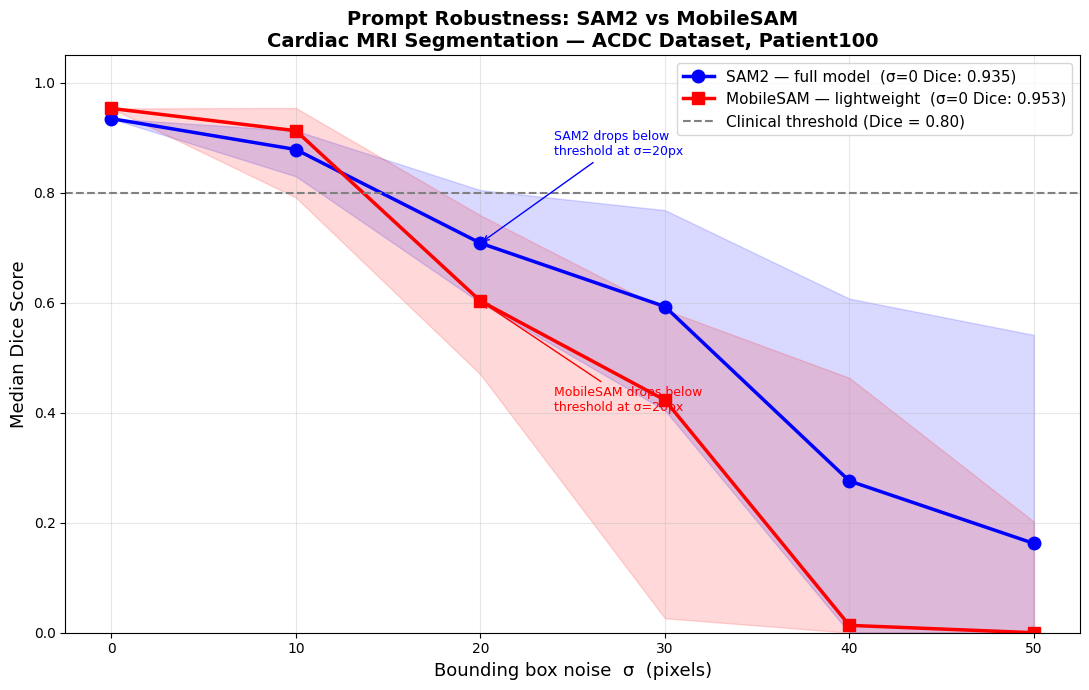

Saved: sam2_vs_mobilesam.png

Figure values (must match Cell 2 table medians):
----------------------------------------------------
σ      SAM2 med     Mobile med   Gap
0      0.9349       0.9535       -0.0186
10     0.8787       0.9129       -0.0342
20     0.7085       0.6033       +0.1052
30     0.5932       0.4232       +0.1700
40     0.2760       0.0134       +0.2626
50     0.1623       0.0000       +0.1623


In [14]:
# ============================================================
# WEEK 2 CELL 5 — SAM2 vs MobileSAM comparison figure
# Reads median + IQR from the dict results so the figure is
# IDENTICAL to the Cell 2 table. Week 2 deliverable figure.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


def med_iqr(results):
    med = [np.median(results[s]["dice"]) for s in sigma_values]
    q1  = [np.percentile(results[s]["dice"], 25) for s in sigma_values]
    q3  = [np.percentile(results[s]["dice"], 75) for s in sigma_values]
    return med, np.clip(q1, 0, 1), np.clip(q3, 0, 1)


sam2_med,   sam2_lo,   sam2_hi   = med_iqr(sam2_results)
mobile_med, mobile_lo, mobile_hi = med_iqr(mobile_results)

fig, ax = plt.subplots(figsize=(11, 7))

ax.plot(sigma_values, sam2_med,
        'b-o', linewidth=2.5, markersize=9,
        label=f'SAM2 — full model  (σ=0 Dice: {sam2_med[0]:.3f})')
ax.fill_between(sigma_values, sam2_lo, sam2_hi, alpha=0.15, color='blue')

ax.plot(sigma_values, mobile_med,
        'r-s', linewidth=2.5, markersize=9,
        label=f'MobileSAM — lightweight  (σ=0 Dice: {mobile_med[0]:.3f})')
ax.fill_between(sigma_values, mobile_lo, mobile_hi, alpha=0.15, color='red')

ax.axhline(y=0.80, color='gray', linestyle='--',
           linewidth=1.5, label='Clinical threshold (Dice = 0.80)')

# Annotate where each model's MEDIAN first drops below threshold.
# Offset the two labels vertically so they never overlap.
y_offsets = {'SAM2': 0.16, 'MobileSAM': -0.20}
for med, color, name in [(sam2_med, 'blue', 'SAM2'),
                          (mobile_med, 'red', 'MobileSAM')]:
    for s, m in zip(sigma_values, med):
        if m < 0.80:
            ax.annotate(f'{name} drops below\nthreshold at σ={s}px',
                        xy=(s, m),
                        xytext=(s + 4, m + y_offsets[name]),
                        fontsize=9, color=color,
                        arrowprops=dict(arrowstyle='->', color=color))
            break

ax.set_xlabel("Bounding box noise  σ  (pixels)", fontsize=13)
ax.set_ylabel("Median Dice Score", fontsize=13)
ax.set_title(
    "Prompt Robustness: SAM2 vs MobileSAM\n"
    "Cardiac MRI Segmentation — ACDC Dataset, Patient100",
    fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.set_xticks(sigma_values)

plt.tight_layout()
plt.savefig('sam2_vs_mobilesam.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sam2_vs_mobilesam.png")

# ---- Consistency check: figure values == table values ----
print("\nFigure values (must match Cell 2 table medians):")
print("-" * 52)
print(f"{'σ':<6} {'SAM2 med':<12} {'Mobile med':<12} {'Gap'}")
for i, s in enumerate(sigma_values):
    print(f"{s:<6} {sam2_med[i]:<12.4f} {mobile_med[i]:<12.4f} "
          f"{sam2_med[i] - mobile_med[i]:+.4f}")

In [15]:
# ============================================================
# WEEK 2 CELL 6 — Summary table: size vs accuracy vs robustness
# Uses median (consistent with Cells 2 & 5) and dict result access.
# ============================================================

import numpy as np


def med(res, sigma):
    return np.median(res[sigma]["dice"])


print("\n" + "=" * 74)
print("WEEK 2 SUMMARY — SAM2 vs MobileSAM on Cardiac MRI (ACDC)")
print("=" * 74)
print(f"{'Model':<14} {'Size':<10} {'Dice σ=0':<12} {'Dice σ=20':<12} "
      f"{'Dice σ=40':<12} {'Drops at'}")
print("-" * 74)

for name, res, size in [
    ("SAM2",      sam2_results,   "~180MB"),
    ("MobileSAM", mobile_results, "~10MB"),
]:
    d0  = med(res, 0)
    d20 = med(res, 20)
    d40 = med(res, 40)
    # First sigma whose MEDIAN drops below the clinical threshold
    drop_at = "Never"
    for s in sigma_values:
        if med(res, s) < 0.80:
            drop_at = f"σ={s}px"
            break
    print(f"{name:<14} {size:<10} {d0:<12.3f} {d20:<12.3f} "
          f"{d40:<12.3f} {drop_at}")

print("=" * 74)

# ---- Key finding: does MobileSAM degrade faster? ----
# Use the paired gap (same boxes) and judge at σ=40, the decisive
# separation point. σ=50 is excluded: both models are near floor there,
# so its gap is noise.
print("\nKey finding: Does MobileSAM degrade faster than SAM2?")
print("-" * 56)

gap_0  = med(sam2_results, 0)  - med(mobile_results, 0)
gap_20 = med(sam2_results, 20) - med(mobile_results, 20)
gap_40 = med(sam2_results, 40) - med(mobile_results, 40)

print(f"  Median Dice gap at σ=0px:   {gap_0:+.3f}  "
      f"({'tied/MobileSAM' if gap_0 <= 0.02 else 'SAM2'})")
print(f"  Median Dice gap at σ=20px:  {gap_20:+.3f}")
print(f"  Median Dice gap at σ=40px:  {gap_40:+.3f}")

if gap_40 > gap_0 + 0.05:
    print("\n  → Gap widens substantially under noise:")
    print("    MobileSAM is competitive on clean prompts but markedly")
    print("    LESS robust to prompt degradation (expected distillation cost).")
elif gap_40 > gap_0:
    print("\n  → Gap widens modestly under noise: MobileSAM somewhat less robust.")
else:
    print("\n  → Gap does not widen: comparable robustness despite size difference.")

# Paired per-trial confirmation at σ=40 (valid: identical boxes)
diffs_40 = (np.array(sam2_results[40]["dice"])
            - np.array(mobile_results[40]["dice"]))
wins = int(np.sum(diffs_40 > 0))
print(f"\n  Paired check at σ=40px: SAM2 wins {wins}/{len(diffs_40)} trials "
      f"(median Δ = {np.median(diffs_40):+.3f})")


WEEK 2 SUMMARY — SAM2 vs MobileSAM on Cardiac MRI (ACDC)
Model          Size       Dice σ=0     Dice σ=20    Dice σ=40    Drops at
--------------------------------------------------------------------------
SAM2           ~180MB     0.935        0.709        0.276        σ=20px
MobileSAM      ~10MB      0.953        0.603        0.013        σ=20px

Key finding: Does MobileSAM degrade faster than SAM2?
--------------------------------------------------------
  Median Dice gap at σ=0px:   -0.019  (tied/MobileSAM)
  Median Dice gap at σ=20px:  +0.105
  Median Dice gap at σ=40px:  +0.263

  → Gap widens substantially under noise:
    MobileSAM is competitive on clean prompts but markedly
    LESS robust to prompt degradation (expected distillation cost).

  Paired check at σ=40px: SAM2 wins 27/50 trials (median Δ = +0.018)


Files in /content/:
 - .config
 - week2_clean_comparison.png
 - mobile_sam.pt
 - yellow-labrador-retriever-on-green-grass-lawn.jpg
 - sam2_vs_mobilesam.png
 - drive
 - sam2_small.pt
 - sample_data

Dog image loaded: (717, 1200, 3)


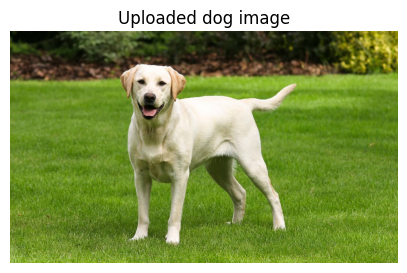

In [17]:
# ============================================================
# CELL 10 — Same experiment on a natural image (dog)
# Using locally uploaded image from Colab files
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from PIL import Image

# ---- Load from Colab uploaded file ----
# Check what filename you uploaded
import os
uploaded_files = os.listdir('/content/')
print("Files in /content/:")
for f in uploaded_files:
    print(f" - {f}")

IMAGE_PATH = '/content/yellow-labrador-retriever-on-green-grass-lawn.jpg'

dog_image = Image.open(IMAGE_PATH).convert("RGB")
dog_np    = np.array(dog_image)

print(f"\nDog image loaded: {dog_np.shape}")

# Show it
plt.figure(figsize=(5,5))
plt.imshow(dog_np)
plt.title("Uploaded dog image")
plt.axis('off')
plt.show()

In [19]:
# ============================================================
# WEEK 2 CELL 3 — Run BOTH models on the Labrador
# Metric: Dice vs ground truth (dog_gt) — consistent with the MRI cells.
# Both models evaluated on the IDENTICAL shared boxes per sigma.
# ============================================================

import numpy as np
import torch
from PIL import Image
from scipy import ndimage

# ---- Load dog photo ----
IMAGE_PATH = '/content/yellow-labrador-retriever-on-green-grass-lawn.jpg'
lab_image  = np.array(Image.open(IMAGE_PATH).convert("RGB"))
H_lab, W_lab = lab_image.shape[:2]
print(f"Dog image shape: {lab_image.shape}")

# ---- Dog box (MATCHES Cell 10: 0.10 / 0.05 / 0.90 / 0.95) ----
lab_box = np.array([
    int(W_lab * 0.10), int(H_lab * 0.05),
    int(W_lab * 0.90), int(H_lab * 0.95),
])

# ---- Load + binarize verified GT mask, resized to the photo ----
DOG_GT_PATH = '/content/lab-ground-truth.png'
gt_img = Image.open(DOG_GT_PATH).convert("RGB").resize((W_lab, H_lab), Image.NEAREST)
dog_gt = (np.array(gt_img).max(axis=2) > 50).astype(np.uint8)
lbl, n = ndimage.label(dog_gt)          # drop the Gemini sparkle watermark
if n > 1:
    sizes = ndimage.sum(np.ones_like(dog_gt), lbl, range(1, n + 1))
    dog_gt = (lbl == (np.argmax(sizes) + 1)).astype(np.uint8)
assert dog_gt.shape == (H_lab, W_lab), "dog_gt must match the dog photo"


def make_noisy_box(clean_box, sigma, seed, W, H):
    """Deterministic noisy box — identical output for any caller."""
    rng = np.random.default_rng(seed)
    if sigma == 0:
        return clean_box.copy().astype(int)
    b = clean_box + rng.normal(0, sigma, 4).astype(int)
    b[0] = int(np.clip(b[0], 0, W - 1))
    b[1] = int(np.clip(b[1], 0, H - 1))
    b[2] = int(np.clip(b[2], 0, W - 1))
    b[3] = int(np.clip(b[3], 0, H - 1))
    if b[0] >= b[2]: b[2] = b[0] + 10
    if b[1] >= b[3]: b[3] = b[1] + 10
    return b


# Shared boxes computed ONCE -> both models see identical prompts.
lab_boxes = {
    sigma: [make_noisy_box(lab_box, sigma, 1000 * sigma + t, W_lab, H_lab)
            for t in range(n_trials)]
    for sigma in sigma_values
}


def run_dog(predictor):
    predictor.set_image(lab_image)
    out = {}
    for sigma in sigma_values:
        dice_list, masks = [], []
        for box in lab_boxes[sigma]:
            with torch.inference_mode():
                m, _, _ = predictor.predict(
                    point_coords=None, point_labels=None,
                    box=box[None, :], multimask_output=False,
                )
            dice_list.append(dice_score(m[0], dog_gt))   # Dice vs GT
            masks.append(m[0])
        out[sigma] = {"dice": dice_list, "masks": masks, "boxes": lab_boxes[sigma]}
    return out


print("Running SAM2 on Labrador...")
lab_sam2_results   = run_dog(sam2_predictor)

print("Running MobileSAM on Labrador...")
lab_mobile_results = run_dog(mobile_predictor)

print("\nLabrador experiments done.")
print(f"SAM2 on dog      σ=0 median Dice: {np.median(lab_sam2_results[0]['dice']):.3f}")
print(f"MobileSAM on dog σ=0 median Dice: {np.median(lab_mobile_results[0]['dice']):.3f}")

# Quick table
print("\n" + "=" * 60)
print(f"{'σ (px)':<10} {'SAM2 Dice':<14} {'MobileSAM Dice':<16} {'Gap'}")
print("-" * 60)
for s in sigma_values:
    s2 = np.median(lab_sam2_results[s]["dice"])
    mb = np.median(lab_mobile_results[s]["dice"])
    print(f"{s:<10} {s2:<14.4f} {mb:<16.4f} {s2 - mb:+.4f}")
print("=" * 60)

Dog image shape: (717, 1200, 3)
Running SAM2 on Labrador...
Running MobileSAM on Labrador...

Labrador experiments done.
SAM2 on dog      σ=0 median Dice: 0.991
MobileSAM on dog σ=0 median Dice: 0.985

σ (px)     SAM2 Dice      MobileSAM Dice   Gap
------------------------------------------------------------
0          0.9911         0.9851           +0.0060
10         0.9907         0.9852           +0.0056
20         0.9903         0.9851           +0.0052
30         0.9900         0.9851           +0.0049
40         0.9890         0.9852           +0.0038
50         0.9859         0.9851           +0.0008


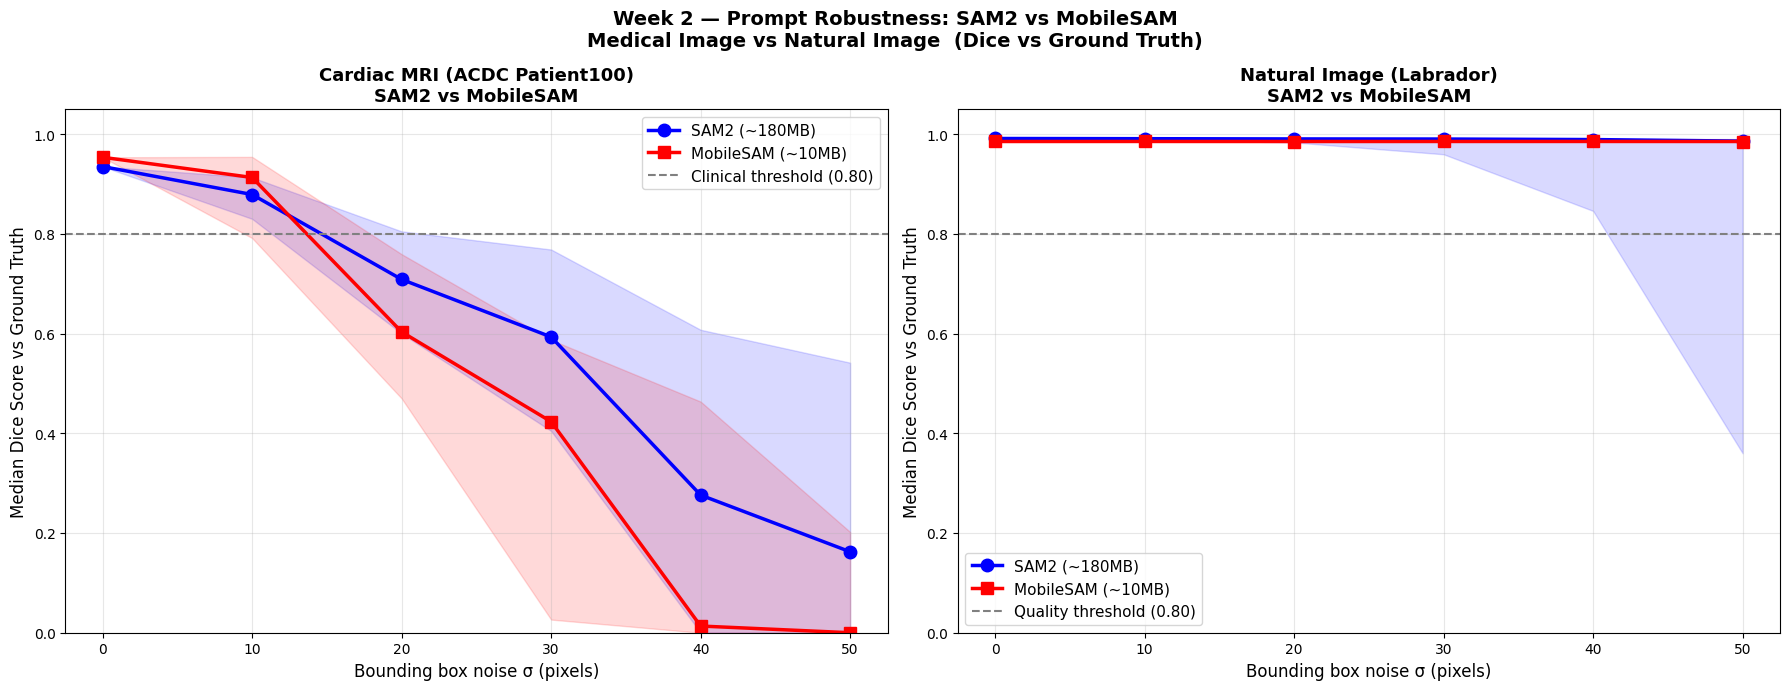

Saved: week2_full_comparison.png

MRI panel (median Dice vs GT):
σ      SAM2       MobileSAM 
0      0.9349     0.9535    
10     0.8787     0.9129    
20     0.7085     0.6033    
30     0.5932     0.4232    
40     0.2760     0.0134    
50     0.1623     0.0000    

Labrador panel (median Dice vs GT):
σ      SAM2       MobileSAM 
0      0.9911     0.9851    
10     0.9907     0.9852    
20     0.9903     0.9851    
30     0.9900     0.9851    
40     0.9890     0.9852    
50     0.9859     0.9851    


In [20]:
# ============================================================
# WEEK 2 CELL 4 — Two-panel comparison figure
# Both panels: median Dice vs GROUND TRUTH + IQR band.
# Left = Cardiac MRI, Right = Natural image (Labrador).
# Same metric, same y-axis -> medical-vs-natural is directly comparable.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


def med_iqr(results):
    """results[sigma] is a dict with key 'dice'. Returns median + clipped IQR."""
    med = [np.median(results[s]["dice"]) for s in sigma_values]
    q1  = [np.percentile(results[s]["dice"], 25) for s in sigma_values]
    q3  = [np.percentile(results[s]["dice"], 75) for s in sigma_values]
    return med, np.clip(q1, 0, 1), np.clip(q3, 0, 1)


def plot_panel(ax, sam2_res, mobile_res, title, threshold_label):
    s2_med, s2_lo, s2_hi = med_iqr(sam2_res)
    mb_med, mb_lo, mb_hi = med_iqr(mobile_res)

    ax.plot(sigma_values, s2_med, 'b-o', linewidth=2.5, markersize=9,
            label='SAM2 (~180MB)')
    ax.fill_between(sigma_values, s2_lo, s2_hi, alpha=0.15, color='blue')

    ax.plot(sigma_values, mb_med, 'r-s', linewidth=2.5, markersize=9,
            label='MobileSAM (~10MB)')
    ax.fill_between(sigma_values, mb_lo, mb_hi, alpha=0.15, color='red')

    ax.axhline(y=0.80, color='gray', linestyle='--', linewidth=1.5,
               label=threshold_label)

    ax.set_xlabel("Bounding box noise σ (pixels)", fontsize=12)
    ax.set_ylabel("Median Dice Score vs Ground Truth", fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(sigma_values)


fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plot_panel(
    axes[0], sam2_results, mobile_results,
    "Cardiac MRI (ACDC Patient100)\nSAM2 vs MobileSAM",
    "Clinical threshold (0.80)")

plot_panel(
    axes[1], lab_sam2_results, lab_mobile_results,
    "Natural Image (Labrador)\nSAM2 vs MobileSAM",
    "Quality threshold (0.80)")

plt.suptitle(
    "Week 2 — Prompt Robustness: SAM2 vs MobileSAM\n"
    "Medical Image vs Natural Image  (Dice vs Ground Truth)",
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('week2_full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: week2_full_comparison.png")

# ---- Consistency print: every plotted point, both panels ----
print("\nMRI panel (median Dice vs GT):")
print(f"{'σ':<6} {'SAM2':<10} {'MobileSAM':<10}")
for i, s in enumerate(sigma_values):
    print(f"{s:<6} {np.median(sam2_results[s]['dice']):<10.4f} "
          f"{np.median(mobile_results[s]['dice']):<10.4f}")

print("\nLabrador panel (median Dice vs GT):")
print(f"{'σ':<6} {'SAM2':<10} {'MobileSAM':<10}")
for i, s in enumerate(sigma_values):
    print(f"{s:<6} {np.median(lab_sam2_results[s]['dice']):<10.4f} "
          f"{np.median(lab_mobile_results[s]['dice']):<10.4f}")

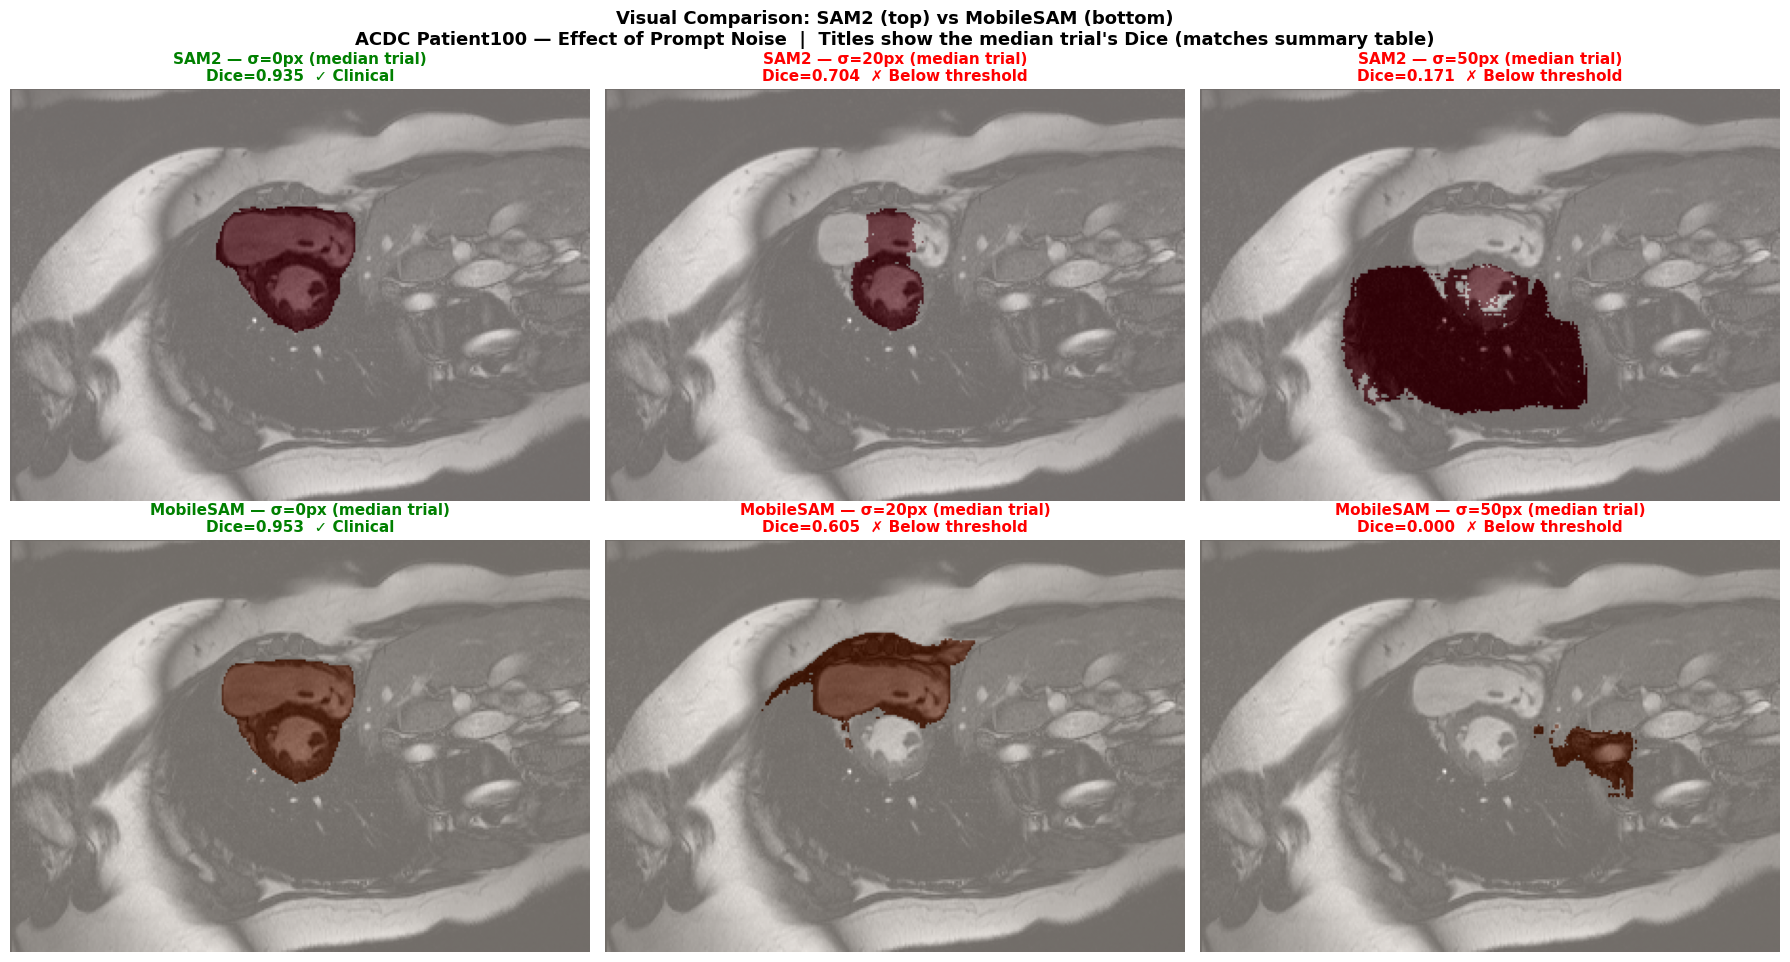

Saved: week2_visual_noise.png


In [21]:
# ============================================================
# WEEK 2 CELL 5 (visual) — SAM2 vs MobileSAM noise panels
# Each panel shows the STORED median trial for that model+sigma,
# so the displayed mask, box, and titled Dice all match the
# Cell 2 table and the curves. No fresh random draws.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

noise_levels = [0, 20, 50]


def median_trial_index(dice_list):
    arr = np.array(dice_list)
    return int(np.argmin(np.abs(arr - np.median(arr))))


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, sigma in enumerate(noise_levels):

    for row, (res, predictor, cmap, model) in enumerate([
        (sam2_results,   sam2_predictor,   'Reds',    'SAM2'),
        (mobile_results, mobile_predictor, 'Oranges', 'MobileSAM'),
    ]):
        dl  = res[sigma]["dice"]
        i   = median_trial_index(dl)
        box = res[sigma]["boxes"][i] if "boxes" in res[sigma] else None
        d   = dl[i]                      # stored value -> matches table

        # Prefer the stored mask; recompute only if masks weren't saved.
        if "masks" in res[sigma]:
            mask = res[sigma]["masks"][i]
        else:
            predictor.set_image(mri_rgb)
            import torch
            with torch.inference_mode():
                m, _, _ = predictor.predict(
                    point_coords=None, point_labels=None,
                    box=box[None, :], multimask_output=False)
            mask = m[0]

        ax = axes[row][col]
        ax.imshow(mri_rgb, cmap='gray')
        ax.imshow(mask, alpha=0.45, cmap=cmap)
        if box is not None:
            ax.add_patch(patches.Rectangle(
                (box[0], box[1]), box[2] - box[0], box[3] - box[1],
                linewidth=2, edgecolor='lime' if sigma == 0 else 'yellow',
                facecolor='none'))
        status = "✓ Clinical" if d >= 0.80 else "✗ Below threshold"
        ax.set_title(
            f"{model} — σ={sigma}px (median trial)\n"
            f"Dice={d:.3f}  {status}",
            fontsize=11, fontweight='bold',
            color='green' if d >= 0.80 else 'red')
        ax.axis('off')

plt.suptitle(
    "Visual Comparison: SAM2 (top) vs MobileSAM (bottom)\n"
    "ACDC Patient100 — Effect of Prompt Noise  |  "
    "Titles show the median trial's Dice (matches summary table)",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('week2_visual_noise.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: week2_visual_noise.png")